In [1]:
import matplotlib.pyplot as plt
from torch_geometric.nn.models import DimeNetPlusPlus
from torch import nn
from torch_geometric.loader import DataLoader
import torch
from polymer_project_compact.src.visualisation import plot_scatter
from polymer_project_compact.src.prediction import predict_1d_target
from polymer_project_compact.src.training import train
from polymer_project_compact.src.load_data import load_data_files, load_data_list
from sklearn.metrics import mean_absolute_error

# Pretrain

In [2]:
directory_pretrain = r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project_compact\data\NREL_opv\NREL_opv_dataset_DFT_geom_to_prop_dimenet_extrapol_filter_1-2.4'

data_pretrain = load_data_files(directory_pretrain, target=0, exclude_atom=1)

KeyboardInterrupt: 

In [ ]:
params = {
    'hidden_channels': 256,
    'out_channels': 1,
    'num_blocks': 4,
    'max_num_neighbors': 64,
    'int_emb_size': 64,
    'basis_emb_size': 8,
    'out_emb_channels': 256,
    'num_spherical': 4,
    'num_radial': 3,
    'output_initializer': 'zeros',
    'cutoff': 5,
    'envelope_exponent': 5,
    'num_before_skip': 1,
    'num_after_skip': 2,
    'num_output_layers': 4,
    'act': 'swish'
}

model_pretrain = DimeNetPlusPlus(**params).to('cuda')

optimizer = torch.optim.AdamW(model_pretrain.parameters(), lr=0.0008, weight_decay=0.0, amsgrad=True)
loss_function = nn.MSELoss().to('cuda')

In [8]:
from sklearn.preprocessing import QuantileTransformer, RobustScaler, PowerTransformer

train_data_list_pretrain, val_data_list_pretrain, test_data_list_pretrain = load_data_list(train_size=0.8, val_size=0.1, data_list=data_pretrain)

train_y_pretrain = torch.cat([data.y for data in train_data_list_pretrain]).numpy()

transform_function = PowerTransformer(method='box-cox')
# transform_function = RobustScaler()
train_y_pretrain_transformed = transform_function.fit_transform(train_y_pretrain.reshape(-1, 1))

def apply_transform(data_list, transformer):
    for data in data_list:
        y_numpy = data.y.numpy()
        y_transformed = transformer.transform(y_numpy.reshape(-1, 1))
        data.y = torch.tensor(y_transformed, dtype=torch.float32)

apply_transform(train_data_list_pretrain, transform_function)
apply_transform(val_data_list_pretrain, transform_function)
apply_transform(test_data_list_pretrain, transform_function)

train_loader_pretrain = DataLoader(train_data_list_pretrain, batch_size=100, shuffle=True, pin_memory=True, num_workers=0)
val_loader_pretrain = DataLoader(val_data_list_pretrain, batch_size=100, shuffle=False, pin_memory=True, num_workers=0)
test_loader_pretrain = DataLoader(test_data_list_pretrain, batch_size=100, shuffle=False, pin_memory=False, num_workers=0)

## Train cycle

In [ ]:
train(model_pretrain, optimizer, loss_function,
      num_epochs=50,
      train_loader=train_loader_pretrain,
      val_loader=val_loader_pretrain,
      ylim=[0, 0.15],
      save_model=False)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
prediction_pretrain = predict_1d_target(model_pretrain, data_loaders=[train_loader_pretrain, val_loader_pretrain, test_loader_pretrain])

y_train_pred_pretrain, y_train_true_pretrain = prediction_pretrain[0]

y_test_pred_pretrain, y_test_true_pretrain = prediction_pretrain[1]

In [ ]:
y_train_pred_t_pretrain = transform_function.inverse_transform(y_train_pred_pretrain.reshape(-1, 1)).flatten()
y_train_true_t_pretrain = transform_function.inverse_transform(y_train_true_pretrain.reshape(-1, 1)).flatten()

y_test_pred_t_pretrain = transform_function.inverse_transform(y_test_pred_pretrain.reshape(-1, 1)).flatten()
y_test_true_t_pretrain = transform_function.inverse_transform(y_test_true_pretrain.reshape(-1, 1)).flatten()

In [ ]:
plot_scatter(y_train_true_t_pretrain, y_train_pred_t_pretrain,
             axis_lims=[0.9, 2.6, 0.9, 2.6],
             s=5,
             graph_title='Тренировочные данные',
             x_label='Расчет TD-DFT, ev')

plot_scatter(y_test_true_t_pretrain, y_test_pred_t_pretrain,
             axis_lims=[0.9, 2.6, 0.9, 2.6],
             s=5,
             graph_title='Тестовые данные',
             x_label='Расчет TD-DFT, ev')

In [ ]:
mae_train_pretrain = mean_absolute_error(y_train_true_t_pretrain, y_train_pred_t_pretrain)
mae_test_pretrain = mean_absolute_error(y_test_true_t_pretrain, y_test_pred_t_pretrain)

print(f'MAE Train: {mae_train_pretrain:.4f}')
print(f'MAE Test: {mae_test_pretrain:.4f}')

# Fine-tuning

In [9]:
params = {
    'hidden_channels': 256,
    'out_channels': 1,
    'num_blocks': 4,
    'max_num_neighbors': 64,
    'int_emb_size': 64,
    'basis_emb_size': 8,
    'out_emb_channels': 256,
    'num_spherical': 4,
    'num_radial': 3,
    'output_initializer': 'zeros',
    'cutoff': 3,
    'envelope_exponent': 5,
    'num_before_skip': 1,
    'num_after_skip': 2,
    'num_output_layers': 4,
    'act': 'swish'
}

model = DimeNetPlusPlus(**params).to('cuda')

loss_function = nn.MSELoss().to('cuda')
# loss_function = nn.HuberLoss().to('cuda')
model.load_state_dict(torch.load(r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project_compact\models\extrapolation_based\DimeNet_NREL_gap_pretrained_filter_1-2.4_v_1.pt'))

<All keys matched successfully>

In [10]:
directory_fine_tune = r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project_compact\data\polymers\poly_v_2_graph_geom_to_prop_Hs_dimenet'

data_fine_tune = load_data_files(directory_fine_tune, target=0, exclude_atom=1)

In [11]:
train_data_list_fine_tune, val_data_list_fine_tune, test_data_list_fine_tune = load_data_list(train_size=0.8, val_size=0.1, data_list=data_fine_tune)

train_y_fine_tune = torch.cat([data.y for data in train_data_list_fine_tune]).numpy()

train_y_fine_tune_transformed = transform_function.transform(train_y_fine_tune.reshape(-1, 1))

apply_transform(train_data_list_fine_tune, transform_function)
apply_transform(val_data_list_fine_tune, transform_function)
apply_transform(test_data_list_fine_tune, transform_function)

train_loader_fine_tune = DataLoader(train_data_list_fine_tune, batch_size=150, shuffle=True, pin_memory=False, num_workers=0)
val_loader_fine_tune = DataLoader(val_data_list_fine_tune, batch_size=100, shuffle=False, pin_memory=False, num_workers=0)
test_loader_fine_tune = DataLoader(test_data_list_fine_tune, batch_size=100, shuffle=False, pin_memory=False, num_workers=0)

## Train cycle

Epoch 1/70 | Train Loss: 1.63039 | Val Loss: 0.42083
Epoch 2/70 | Train Loss: 0.34878 | Val Loss: 0.28636
Epoch 3/70 | Train Loss: 0.31628 | Val Loss: 0.26226
Epoch 4/70 | Train Loss: 0.24083 | Val Loss: 0.25453
Epoch 5/70 | Train Loss: 0.21240 | Val Loss: 0.23345
Epoch 6/70 | Train Loss: 0.19674 | Val Loss: 0.24603
Epoch 7/70 | Train Loss: 0.17511 | Val Loss: 0.22154
Epoch 8/70 | Train Loss: 0.18791 | Val Loss: 0.20200
Epoch 9/70 | Train Loss: 0.14530 | Val Loss: 0.19275
Epoch 10/70 | Train Loss: 0.13437 | Val Loss: 0.18198
Epoch 11/70 | Train Loss: 0.16206 | Val Loss: 0.33500
Epoch 12/70 | Train Loss: 0.15658 | Val Loss: 0.15904
Epoch 13/70 | Train Loss: 0.12042 | Val Loss: 0.19555
Epoch 14/70 | Train Loss: 0.11440 | Val Loss: 0.20594
Epoch 15/70 | Train Loss: 0.13214 | Val Loss: 0.15973
Epoch 16/70 | Train Loss: 0.10765 | Val Loss: 0.14186
Epoch 17/70 | Train Loss: 0.09120 | Val Loss: 0.14457
Epoch 18/70 | Train Loss: 0.08474 | Val Loss: 0.13592
Epoch 19/70 | Train Loss: 0.08191 | V

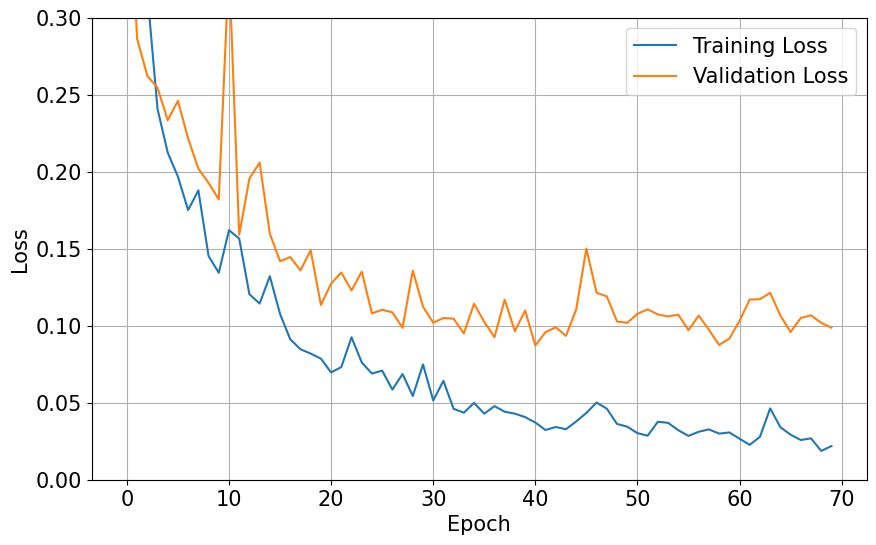

In [12]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.000285, weight_decay=0.0, amsgrad=True)
train(model, optimizer, loss_function, num_epochs=70, train_loader=train_loader_fine_tune, val_loader=val_loader_fine_tune, ylim=[0, 0.3], save_model=False)

In [ ]:
# torch.save(model.state_dict(), r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project\models\trained_models\DimeNet_NREL_homo_extrapol_filter_1-2.4_v_1.pt')

In [13]:
prediction_fine_tune = predict_1d_target(model, data_loaders=[train_loader_fine_tune, val_loader_fine_tune, test_loader_fine_tune])

y_train_pred_fine_tune, y_train_true_fine_tune = prediction_fine_tune[0]

y_test_pred_fine_tune, y_test_true_fine_tune = prediction_fine_tune[1]

In [14]:
y_train_pred_t_fine_tune = transform_function.inverse_transform(y_train_pred_fine_tune.reshape(-1, 1)).flatten()
y_train_true_t_fine_tune = transform_function.inverse_transform(y_train_true_fine_tune.reshape(-1, 1)).flatten()

y_test_pred_t_fine_tune = transform_function.inverse_transform(y_test_pred_fine_tune.reshape(-1, 1)).flatten()
y_test_true_t_fine_tune = transform_function.inverse_transform(y_test_true_fine_tune.reshape(-1, 1)).flatten()

In [17]:
import numpy as np

train_cat = np.concatenate((y_train_pred_t_fine_tune.reshape(-1,1), y_train_true_t_fine_tune.reshape(-1,1)), axis=1)

np.savetxt('gap_train_pred_true.csv', train_cat, delimiter=',')

test_cat = np.concatenate((y_test_pred_t_fine_tune.reshape(-1,1), y_test_true_t_fine_tune.reshape(-1,1)), axis=1)

np.savetxt('gap_test_pred_true.csv', test_cat, delimiter=',')

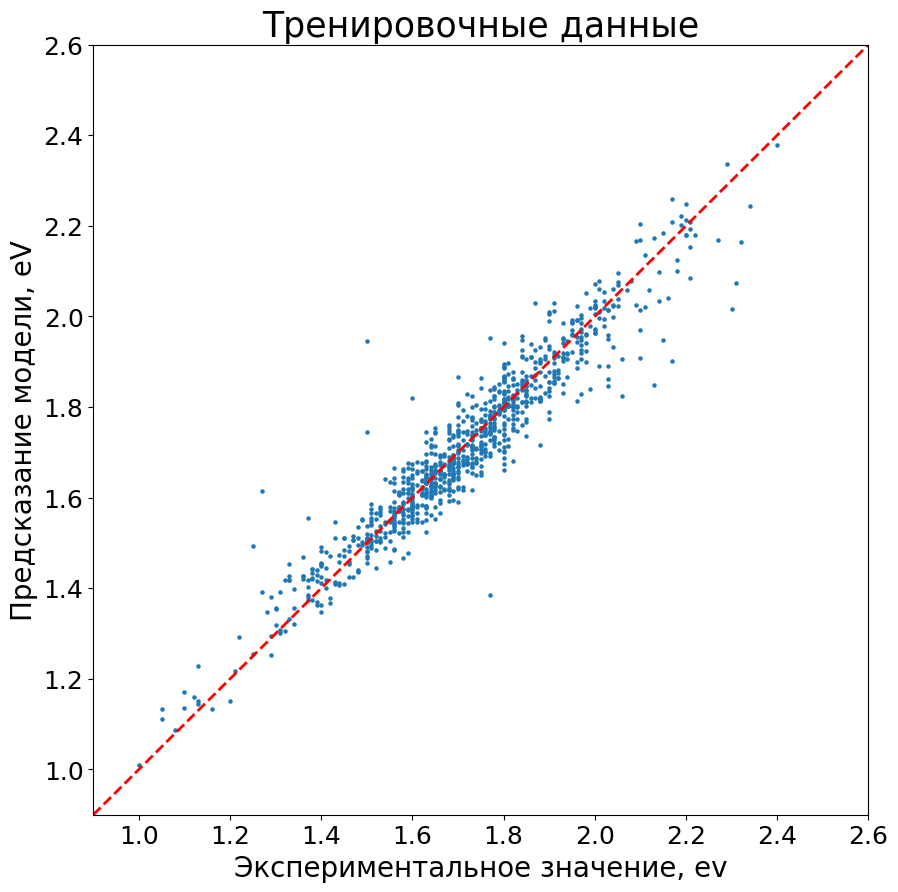

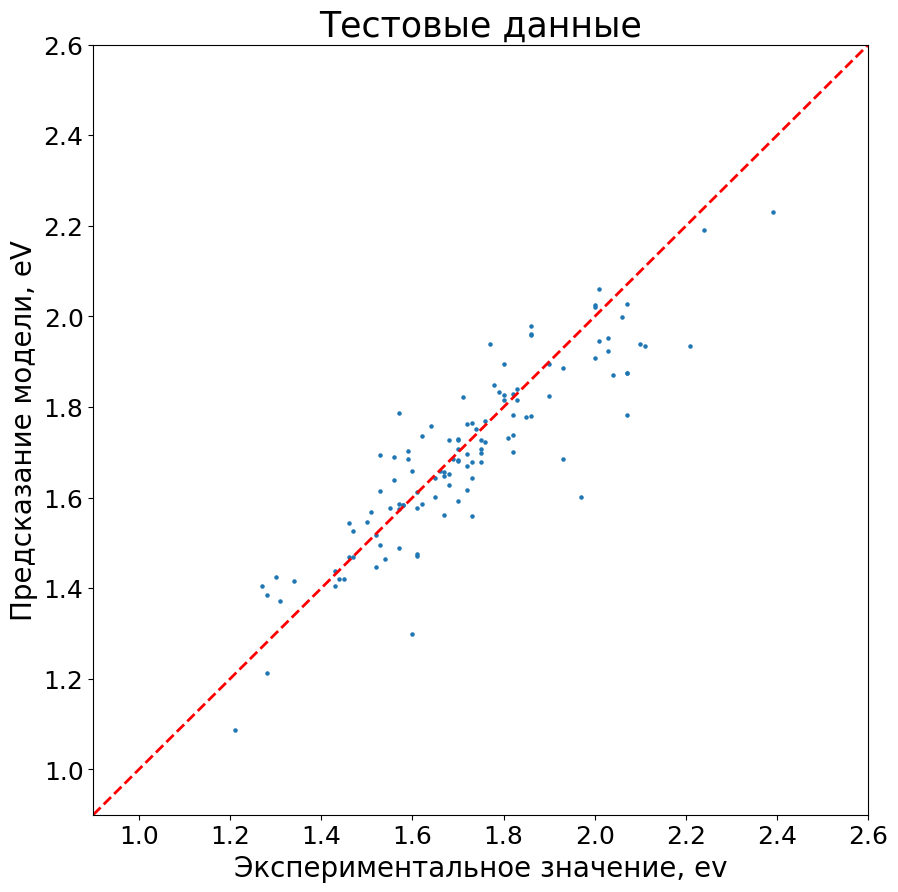

In [18]:
plot_scatter(y_train_true_t_fine_tune, y_train_pred_t_fine_tune,
             axis_lims=[0.9, 2.6, 0.9, 2.6],
             s=5,
             graph_title='Тренировочные данные',
             x_label='Экспериментальное значение, ev')

plot_scatter(y_test_true_t_fine_tune, y_test_pred_t_fine_tune,
             axis_lims=[0.9, 2.6, 0.9, 2.6],
             s=5,
             graph_title='Тестовые данные',
             x_label='Экспериментальное значение, ev')

In [16]:
mae_train_fine_tune = mean_absolute_error(y_train_true_t_fine_tune, y_train_pred_t_fine_tune)
mae_test_fine_tune = mean_absolute_error(y_test_true_t_fine_tune, y_test_pred_t_fine_tune)

print(f'MAE Train: {mae_train_fine_tune:.4f}')
print(f'MAE Test: {mae_test_fine_tune:.4f}')

MAE Train: 0.0434
MAE Test: 0.0759
